<a href="https://colab.research.google.com/github/ota0425/brain-tumor-adversarial-experiment/blob/main/brain_tumor_adversarial_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI画像に対するAdversarial Examplesの実験

## 1. 実験環境の確認
TensorFlowのバージョンとGPUの利用状況を確認する。

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. データセットの準備
Google Driveを接続し、Brain Tumor MRI DatasetをColab上に展開する。

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
!unzip -oq "/content/drive/MyDrive/ThammasatResearch/dataset/archive.zip" -d "/content/brain_tumor"
print("展開完了")

展開完了


In [6]:
!find /content/brain_tumor -maxdepth 3 -type d

/content/brain_tumor
/content/brain_tumor/Training
/content/brain_tumor/Training/glioma
/content/brain_tumor/Training/pituitary
/content/brain_tumor/Training/meningioma
/content/brain_tumor/Training/notumor
/content/brain_tumor/Testing
/content/brain_tumor/Testing/glioma
/content/brain_tumor/Testing/pituitary
/content/brain_tumor/Testing/meningioma
/content/brain_tumor/Testing/notumor


## 3. データセットの画像枚数を確認

TrainingとTestingについて、クラスごとの画像枚数を確認する。

In [7]:
from pathlib import Path

data_dir = Path("/content/brain_tumor")
train_dir = data_dir / "Training"
test_dir = data_dir / "Testing"

image_extensions = {".jpg", ".jpeg", ".png"}

def count_images(directory):
    return sum(
        1 for file in directory.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

for split_name, split_dir in [
    ("Training", train_dir),
    ("Testing", test_dir)
]:
    print(f"\n{split_name}")

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            print(f"{class_dir.name}: {count_images(class_dir)} images")


Training
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

Testing
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


## 4. MRI画像の確認

各クラスから2枚ずつ画像を選び、データが正しく読み込まれていることを確認する。

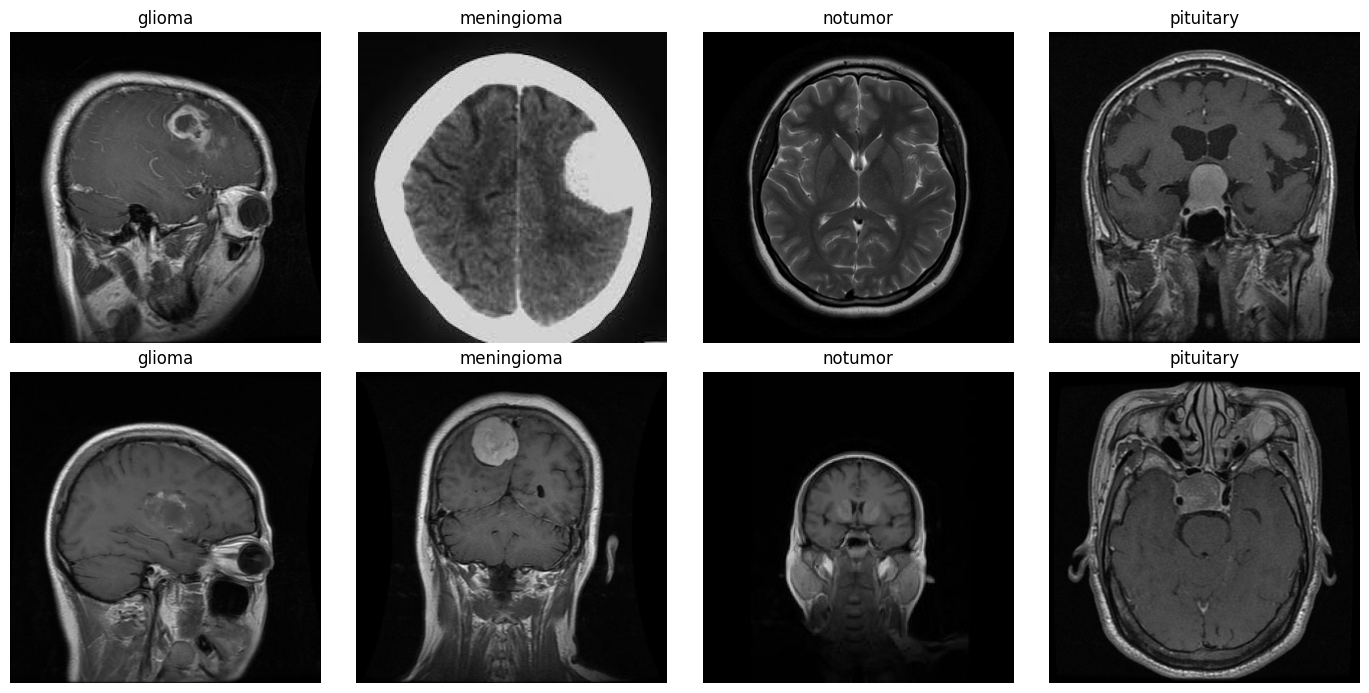

In [8]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

class_names = sorted([
    directory.name
    for directory in train_dir.iterdir()
    if directory.is_dir()
])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for column, class_name in enumerate(class_names):
    class_dir = train_dir / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    selected_images = random.sample(image_files, 2)

    for row, image_path in enumerate(selected_images):
        image = Image.open(image_path)

        axes[row, column].imshow(image, cmap="gray")
        axes[row, column].set_title(class_name)
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

## 5. TensorFlowデータセットの作成

Trainingフォルダの80%を学習用、20%を検証用として使用する。
Testingフォルダは最終評価だけに使用する。
すべての画像を224×224に変換する。

In [9]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32
random_seed = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    str(train_dir),
    validation_split=0.2,
    subset="training",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    str(train_dir),
    validation_split=0.2,
    subset="validation",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    str(test_dir),
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [10]:
class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)),
          "to", float(tf.reduce_max(images)))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


## 6. MobileNetV2モデルの作成

ImageNetで事前学習されたMobileNetV2を使用する。
最初はベースモデルの重みを固定し、最後の分類層だけを学習する。

In [11]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# MobileNetV2の学習済み部分を固定
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. ベースラインモデルの学習

MobileNetV2の事前学習済み部分を固定し、MRI画像を分類する出力層を学習する。
検証精度が最も高いモデルをGoogle Driveに保存する。

In [13]:
import os

# データ読み込みを高速化
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# モデルの保存先
model_directory = (
    "/content/drive/MyDrive/ThammasatResearch/models"
)

os.makedirs(model_directory, exist_ok=True)

model_path = (
    model_directory + "/baseline_mobilenetv2.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

In [14]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6298 - loss: 0.8962
Epoch 1: val_accuracy improved from None to 0.83125, saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.7440 - loss: 0.6626 - val_accuracy: 0.8313 - val_loss: 0.4391
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8227 - loss: 0.4429
Epoch 2: val_accuracy improved from 0.83125 to 0.85357, saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8348 - loss: 0.4284 - val_accuracy: 0.8536 - val_loss: 0.3862
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8651 - los

## 8. ベースラインモデルのテスト評価

学習時に使用していないTestingデータを用いて、保存したベースラインモデルの性能を評価する。

ここで得られるtest accuracyは、今後FGSMによる敵対的攻撃を行った際の性能低下を比較するための基準値として使用する。

まず、検証精度が最も高かったモデルをGoogle Driveから読み込み、通常のテスト画像に対するlossとaccuracyを測定する。

In [15]:
import tensorflow as tf
import os

# 保存したベストモデルのパス
model_path = "/content/drive/MyDrive/ThammasatResearch/models/baseline_mobilenetv2.keras"

# モデルが存在するか確認
print("Model exists:", os.path.exists(model_path))

# ベストモデルを読み込み
best_model = tf.keras.models.load_model(model_path)

print("Best model loaded successfully.")

Model exists: True
Best model loaded successfully.


In [16]:
# 未使用のTestingデータで評価
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8319 - loss: 0.5203
Test Loss: 0.5203
Test Accuracy: 0.8319
Test Accuracy: 83.19%


### 8.1 評価結果

Testingデータに対する分類性能を測定した。

- Test Loss: 0.5203
- Test Accuracy: 0.8319 (83.19%)

最高Validation Accuracyは91.071%であったのに対し、未使用のTestingデータでは83.19%のAccuracyとなった。

この結果を、FGSMによる敵対的サンプルに対する分類性能を評価する際のベースラインとして使用する。

## 9. 詳細な分類性能の評価

Accuracyだけでなく、各クラスに対する分類性能を確認するため、Testingデータに対してConfusion Matrix、Precision、Recall、F1-scoreを計算する。

これにより、ベースラインモデルがどのクラスを正しく分類できているか、またどのクラス間で誤分類が発生しているかを確認する。

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# class_namesはprefetch適用前（セル13）に保存済み
# PrefetchDatasetにはclass_names属性がないため、既存の変数を使用する

print("Class mapping:")
for i, name in enumerate(class_names):
    print(f"Class {i}: {name}")

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    # labelsがone-hotの場合
    if len(labels.shape) > 1:
        true_classes = np.argmax(labels.numpy(), axis=1)
    else:
        true_classes = labels.numpy()

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nNumber of test images:", len(y_true))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Class mapping:
Class 0: glioma
Class 1: meningioma
Class 2: notumor
Class 3: pituitary

Number of test images: 1600

Confusion Matrix:
[[259 103  19  19]
 [ 16 293  26  65]
 [  0  12 387   1]
 [  3   5   0 392]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.65      0.76       400
  meningioma       0.71      0.73      0.72       400
     notumor       0.90      0.97      0.93       400
   pituitary       0.82      0.98      0.89       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



## 10. FGSMによる敵対的攻撃

保存済みMobileNetV2モデルに対して、untargeted white-box FGSMを適用する。

モデルは画素値0–255の画像を入力として受け取り、モデル内部でMobileNetV2の`preprocess_input`を適用している。そのため、FGSMの摂動強度εも0–255スケールで指定する。

ε = 1でも攻撃後Accuracyが3.31%まで低下した予備実験を受け、性能低下が立ち上がる微小摂動領域を詳細に評価する。

- ε = 0
- ε = 0.01
- ε = 0.05
- ε = 0.1
- ε = 0.25
- ε = 0.5
- ε = 1

これらはすべて0–255入力スケールの値である。このセクションに保存されている現在の出力はε = 0, 1, 2, 4, 8の予備実験結果であり、以下のセルを再実行すると微小εの結果に更新される。

敵対的画像は次式で生成する。

\[
x_{adv} = \mathrm{clip}(x + \epsilon \cdot \mathrm{sign}(\nabla_x J(model(x), y)), 0, 255)
\]

攻撃は正解ラベルを使用するuntargeted white-box attackとし、元画像と敵対的画像には同一のTestingデータを使用する。

Attack Success Rateは、攻撃前に正しく分類された画像のうち、FGSM適用後に誤分類となった画像の割合と定義する。

In [ ]:
import tensorflow as tf
import numpy as np

# 0–255入力スケール上の摂動強度
epsilon_values = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1]

loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

def compute_fgsm_direction(model, images, labels):
    """
    入力画像に対する損失勾配の符号を計算する。
    modelは確率（softmax）を出力するため、from_logits=Falseを使用する。
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int32)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = loss_function(labels, predictions)

    gradients = tape.gradient(loss, images)
    signed_gradients = tf.sign(gradients)

    return predictions, signed_gradients


def create_adversarial_images(images, signed_gradients, epsilon):
    """
    FGSMによる敵対的画像を作成し、画素値を0–255に制限する。
    """
    images = tf.cast(images, tf.float32)
    adversarial_images = images + epsilon * signed_gradients
    adversarial_images = tf.clip_by_value(
        adversarial_images,
        clip_value_min=0.0,
        clip_value_max=255.0
    )

    return adversarial_images


print("FGSM functions are ready.")
print("Epsilon values:", epsilon_values)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 各εの予測結果を保存
all_true_labels = []
clean_predictions = []
adversarial_predictions = {
    epsilon: [] for epsilon in epsilon_values
}

for batch_number, (images, labels) in enumerate(test_dataset):
    labels = tf.cast(labels, tf.int32)

    # clean画像の予測とFGSM方向を1回だけ計算
    clean_probabilities, signed_gradients = compute_fgsm_direction(
        best_model,
        images,
        labels
    )

    clean_batch_predictions = tf.argmax(
        clean_probabilities,
        axis=1
    ).numpy()

    all_true_labels.extend(labels.numpy())
    clean_predictions.extend(clean_batch_predictions)

    # 同じ勾配方向を使用して各εの敵対的画像を評価
    for epsilon in epsilon_values:
        adversarial_images = create_adversarial_images(
            images,
            signed_gradients,
            epsilon
        )

        adversarial_probabilities = best_model(
            adversarial_images,
            training=False
        )

        adversarial_batch_predictions = tf.argmax(
            adversarial_probabilities,
            axis=1
        ).numpy()

        adversarial_predictions[epsilon].extend(
            adversarial_batch_predictions
        )

    if (batch_number + 1) % 10 == 0:
        print(f"Processed {batch_number + 1} batches")

all_true_labels = np.array(all_true_labels)
clean_predictions = np.array(clean_predictions)

for epsilon in epsilon_values:
    adversarial_predictions[epsilon] = np.array(
        adversarial_predictions[epsilon]
    )

print("\nEvaluation completed.")
print("Number of test images:", len(all_true_labels))

In [ ]:
import pandas as pd

clean_correct = clean_predictions == all_true_labels
number_of_clean_correct = np.sum(clean_correct)
clean_accuracy = accuracy_score(
    all_true_labels,
    clean_predictions
)

evaluation_results = []

for epsilon in epsilon_values:
    epsilon_predictions = adversarial_predictions[epsilon]

    adversarial_accuracy = accuracy_score(
        all_true_labels,
        epsilon_predictions
    )

    accuracy_drop = clean_accuracy - adversarial_accuracy

    # cleanでは正解、攻撃後は不正解になった画像
    successful_attacks = (
        clean_correct
        & (epsilon_predictions != all_true_labels)
    )

    if number_of_clean_correct > 0:
        attack_success_rate = (
            np.sum(successful_attacks)
            / number_of_clean_correct
        )
    else:
        attack_success_rate = np.nan

    evaluation_results.append({
        "epsilon": epsilon,
        "clean_accuracy": clean_accuracy,
        "adversarial_accuracy": adversarial_accuracy,
        "accuracy_drop": accuracy_drop,
        "attack_success_rate": attack_success_rate,
        "successful_attacks": int(np.sum(successful_attacks)),
        "clean_correct_images": int(number_of_clean_correct)
    })

results_df = pd.DataFrame(evaluation_results)

display(
    results_df.style.format({
        "clean_accuracy": "{:.4f}",
        "adversarial_accuracy": "{:.4f}",
        "accuracy_drop": "{:.4f}",
        "attack_success_rate": "{:.4f}"
    })
)

In [ ]:
from pathlib import Path

results_directory = Path(
    "/content/drive/MyDrive/ThammasatResearch/results"
)
results_directory.mkdir(parents=True, exist_ok=True)

summary_path = results_directory / "fgsm_fine_summary.csv"
results_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

In [ ]:
class_metric_rows = []

for epsilon in epsilon_values:
    report = classification_report(
        all_true_labels,
        adversarial_predictions[epsilon],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    for class_name in class_names:
        class_metric_rows.append({
            "epsilon": epsilon,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": int(report[class_name]["support"])
        })

class_metrics_df = pd.DataFrame(class_metric_rows)

display(
    class_metrics_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}"
    })
)

class_metrics_path = (
    results_directory / "fgsm_fine_class_metrics.csv"
)
class_metrics_df.to_csv(class_metrics_path, index=False)

print("Saved:", class_metrics_path)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    results_df["epsilon"],
    results_df["adversarial_accuracy"],
    marker="o"
)
axes[0].set_title("Adversarial Accuracy by Epsilon")
axes[0].set_xlabel("Epsilon (0–255 scale)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epsilon_values)
axes[0].set_ylim(0, 1)
axes[0].grid(True)

axes[1].plot(
    results_df["epsilon"],
    results_df["attack_success_rate"],
    marker="o",
    color="red"
)
axes[1].set_title("Attack Success Rate by Epsilon")
axes[1].set_xlabel("Epsilon (0–255 scale)")
axes[1].set_ylabel("Attack Success Rate")
axes[1].set_xticks(epsilon_values)
axes[1].set_ylim(0, 1)
axes[1].grid(True)

plt.tight_layout()

curve_path = results_directory / "fgsm_fine_performance_curves.png"
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", curve_path)

In [ ]:
# テストデータの最初のバッチを取得
sample_images, sample_labels = next(iter(test_dataset))

_, sample_signed_gradients = compute_fgsm_direction(
    best_model,
    sample_images,
    sample_labels
)

visualization_epsilon = 0.5

sample_adversarial_images = create_adversarial_images(
    sample_images,
    sample_signed_gradients,
    visualization_epsilon
)

sample_clean_predictions = tf.argmax(
    best_model(sample_images, training=False),
    axis=1
).numpy()

sample_adversarial_predictions = tf.argmax(
    best_model(sample_adversarial_images, training=False),
    axis=1
).numpy()

number_of_examples = 4

fig, axes = plt.subplots(
    number_of_examples,
    3,
    figsize=(12, 4 * number_of_examples)
)

for index in range(number_of_examples):
    original = sample_images[index].numpy()
    adversarial = sample_adversarial_images[index].numpy()
    perturbation = adversarial - original

    # 摂動を見やすい0–1範囲に変換
    perturbation_display = (
        perturbation + visualization_epsilon
    ) / (2 * visualization_epsilon)

    true_name = class_names[int(sample_labels[index])]
    clean_name = class_names[sample_clean_predictions[index]]
    adversarial_name = class_names[
        sample_adversarial_predictions[index]
    ]

    axes[index, 0].imshow(
        original.astype(np.uint8)
    )
    axes[index, 0].set_title(
        f"Original\nTrue: {true_name}, Pred: {clean_name}"
    )
    axes[index, 0].axis("off")

    axes[index, 1].imshow(
        np.clip(perturbation_display, 0, 1)
    )
    axes[index, 1].set_title(
        f"Perturbation\nε = {visualization_epsilon}"
    )
    axes[index, 1].axis("off")

    axes[index, 2].imshow(
        adversarial.astype(np.uint8)
    )
    axes[index, 2].set_title(
        f"Adversarial\nPred: {adversarial_name}"
    )
    axes[index, 2].axis("off")

plt.tight_layout()

example_path = (
    results_directory / "fgsm_fine_adversarial_examples.png"
)
plt.savefig(example_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", example_path)